In [1]:
import sys
sys.path.insert(0, '../lib')

import glob
import os
import pickle
import datetime
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import datasets
import numpy as np
import pandas as pd
import wandb
import scipy
import sklearn.metrics
import statsmodels.stats.multitest

import common_data
import common_plots

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = "retina"

In [3]:
pd.options.display.max_columns = 300
pd.options.display.max_rows = 350
pd.options.display.max_colwidth = 10000

In [4]:
common_plots.setup_plotting()

In [5]:
sc_meta = pd.read_csv('../data/02b_integration/09_final_full-1/09_final_full-1-metadata.csv')

/tmp/ipykernel_1027462/3554345909.py:1: DtypeWarning: Columns (16,17,25,31,32,35,37,40,41,52,54,56,57,58,66) have mixed types. Specify dtype option on import or set low_memory=False.
  sc_meta = pd.read_csv('../data/02b_integration/09_final_full-1/09_final_full-1-metadata.csv')


In [6]:
sc_meta = sc_meta.loc[sc_meta.cohort.eq('LongCOVID')].copy()

In [7]:
sc_meta = sc_meta.groupby('library_id').head(1)

In [8]:
sc_meta.library_id.nunique()

25

In [9]:
sc_meta.individual.nunique()

25

In [10]:
mapping = pd.read_csv('subject_sample_table(in).csv')

In [12]:
mapping = mapping.loc[mapping['BAL Library ID'].notna()].copy()

In [13]:
mapping['BAL Library ID'].nunique()

31

In [14]:
mapping['BAL Library ID'] = mapping['BAL Library ID'].str.split('\\s', regex=True)
mapping = mapping.explode('BAL Library ID')

In [15]:
mapping['BAL Library ID'].nunique()

33

In [16]:
lc_meta = sc_meta[['individual', 'library_id']].merge(
    mapping,
    left_on='library_id',
    right_on='BAL Library ID',
    how='left'
)

In [17]:
lc_meta['Deidentified Subject ID'] = lc_meta['Deidentified Subject ID'].str.split('\\s', regex=True).str[0]

In [18]:
clin_data = pd.read_csv('Supplemental Data File 4. Initial CT scan lung fractions.csv')

In [19]:
lc_meta = lc_meta.merge(clin_data, left_on='Deidentified Subject ID', right_on='Subject_ID', how='left')

In [20]:
lc_meta.shape

(25, 14)

In [21]:
lc_meta = lc_meta.set_index('individual')

In [22]:
pathogen_data = pd.read_csv('./long-covid-pathogens.csv')
pathogen_data.columns = pathogen_data.columns.str.strip()
for col in pathogen_data.columns:
    pathogen_data[col] = pathogen_data[col].str.strip()

In [23]:
lc_meta = lc_meta.reset_index().merge(
    pathogen_data,
    left_on='Deidentified Subject ID',
    right_on='Study ID',
    how='left'
).set_index('individual')

In [24]:
with open('05_long_covid_preds.pkl', 'rb') as f:
    long_covid_preds = pickle.load(f)

In [25]:
per_sample_data = []
for model_path, model_df in long_covid_preds.items():
    for sample in model_df['sample'].unique():
        idx = model_df['sample'].eq(sample)
        assert model_df.true_label[idx].std() == 0
        n_cells = idx.sum()
        sample_info = dict(
            model_path=model_path,
            sample=sample,
            n_cells=n_cells,
            avg_pred=model_df.pred_label[idx].mean(),
            true_label=model_df.true_label[idx].iloc[0]
        )
        per_sample_data.append(sample_info)
per_sample_data = pd.DataFrame(per_sample_data)

In [26]:
per_sample_data['model'] = per_sample_data.model_path.str.split('/').str[-1]
per_sample_data['split'] = per_sample_data.model_path.str.split('/').str[-2]
per_sample_data['task'] = per_sample_data.model_path.str.split('/').str[-3]
per_sample_data = per_sample_data.drop(columns='model_path')

Check that number of cells is equal for different random initializations

In [27]:
assert np.all(per_sample_data.groupby(['sample', 'split', 'task']).n_cells.std() == 0)

Take average across random initializations

In [28]:
per_sample_data_agg = per_sample_data.groupby(['sample', 'split', 'task']).mean().reset_index()

/tmp/ipykernel_1027462/775600844.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_sample_data_agg = per_sample_data.groupby(['sample', 'split', 'task']).mean().reset_index()


In [29]:
long_covid_heatmap = per_sample_data_agg.pivot_table(
    index='sample',
    columns=['task', 'split'],
    values='avg_pred'
)

In [30]:
TASKS_MAP = {
    'H_vs_G+': 'Gram+',
    'H_vs_G-': 'Other Gram–',
    'H_vs_G-_G+': 'Other Gram–; Gram+',
    'H_vs_P': 'Pseudomonas',
    'H_vs_P_COVID': 'SARS-CoV-2; Pseudomonas',
    'H_vs_eCOVID': 'Early SARS-CoV-2',
    'H_vs_eCOVID_G+': 'Early SARS-CoV-2; Gram+',
    'H_vs_lCOVID': 'Late SARS-CoV-2',
    'H_vs_lCOVID_G+': 'Late SARS-CoV-2; Gram+',
}

In [31]:
TASK_ORDER = [
    'H_vs_eCOVID',
    'H_vs_lCOVID',
    'H_vs_G+',
    'H_vs_P',
    'H_vs_G-',
    'H_vs_G-_G+',
    'H_vs_eCOVID_G+',
    'H_vs_lCOVID_G+',
    'H_vs_P_COVID',
]

Text(-1.3885555555555502, 0.5, '')

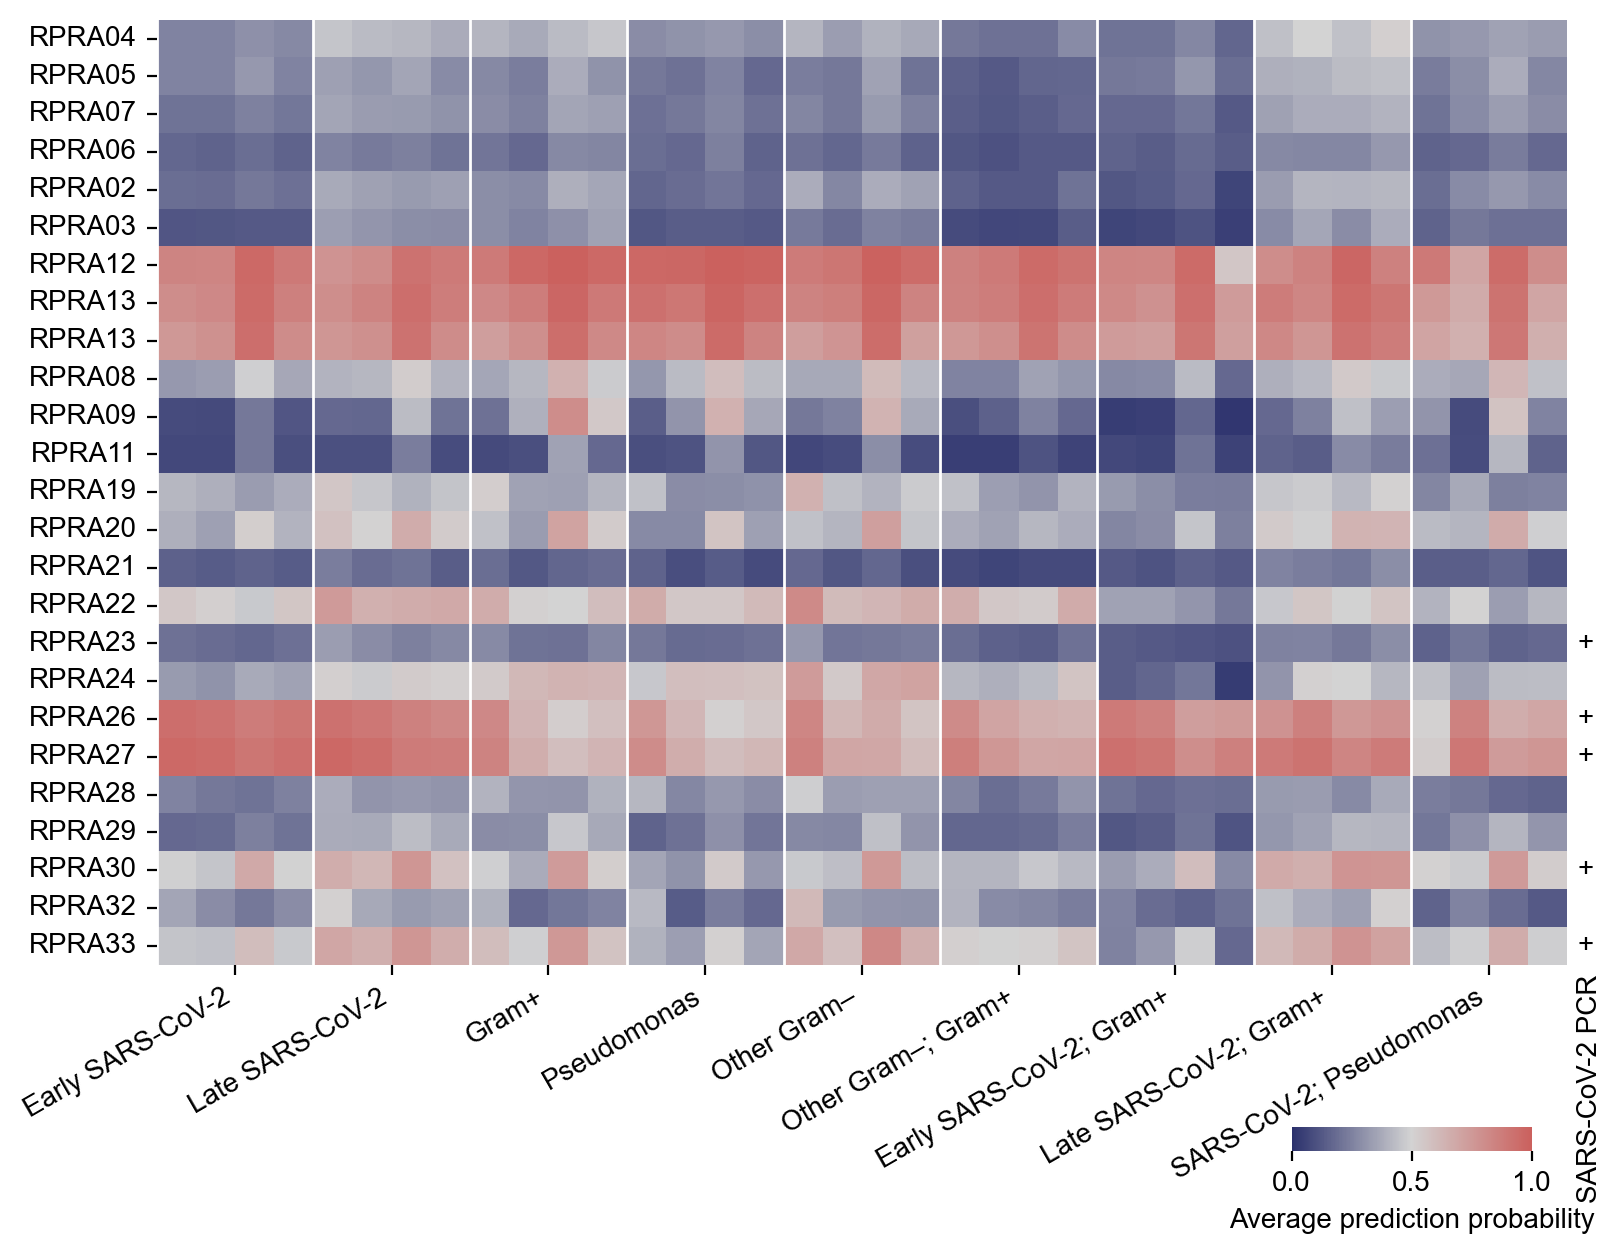

In [32]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

pleasant_blue = '#2a306c'  # Steel Blue
pleasant_red = '#cb615e'   # Indian Red
colors = [pleasant_blue, 'lightgray', pleasant_red]
n_bins = 255
cmap = mpl.colors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

cbar_ax = fig.add_axes((0.8, 0.05, 0.15, 0.02))

sns.heatmap(
    long_covid_heatmap.loc[:, TASK_ORDER],
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1,
    xticklabels=[],
    yticklabels=list(lc_meta['Deidentified Subject ID'][long_covid_heatmap.index]),
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='Average prediction probability',
        orientation='horizontal',
        ticks=[0, 0.5, 1]
    ),
)

x_ticks = []
x_tick_labels = []
for i, task in enumerate(TASK_ORDER):
    x_ticks.append(i * 4 + 2)
    x_tick_labels.append(TASKS_MAP[task])

for i in range(len(TASK_ORDER)):
    ax.axvline(x=i * 4, c='w', lw=1)

ax.set_xticks(x_ticks, labels=x_tick_labels, ha='right', rotation=30)

for i, sample in enumerate(long_covid_heatmap.index):
    pcr = lc_meta['SARS-CoV-2 PCR'][lc_meta.index == sample].iloc[0]
    if pcr == 'Positive':
        ax.annotate(
            '+',
            xy=(long_covid_heatmap.shape[1], i + 0.5),
            xytext=(10, 0),
            textcoords='offset pixels',
            va='center'
        )
ax.annotate(
    'SARS-CoV-2 PCR',
    xy=(long_covid_heatmap.shape[1], long_covid_heatmap.shape[0]),
    xytext=(10, -10),
    textcoords='offset pixels',
    ha='left',
    va='top',
    rotation=90
)

ax.set_xlabel('')
ax.set_ylabel('')

In [33]:
per_sample_data_agg = per_sample_data.groupby(['sample', 'task']).mean().reset_index()

/tmp/ipykernel_1027462/1116638396.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_sample_data_agg = per_sample_data.groupby(['sample', 'task']).mean().reset_index()


In [34]:
long_covid_heatmap = per_sample_data_agg.pivot_table(
    index='sample',
    columns='task',
    values='avg_pred'
)

In [73]:
CAT_ORDER = ['pcr_neg', 'pcr_pos', 'transplant']
CAT_NAMES = {
    'pcr_neg': 'SARS-CoV-2\nPCR–',
    'pcr_pos': 'SARS-CoV-2\nPCR+',
    'transplant': 'Progressive\nfibrosis'
}

sample_order = []
sample_groups = []
sample_borders = []
for cat in CAT_ORDER:
    for sample in long_covid_heatmap.index:
        if sample.startswith('LT'):
            if cat == 'transplant':
                sample_order.append(sample)
                sample_groups.append(cat)
        else:
            if cat == 'pcr_pos' and lc_meta['SARS-CoV-2 PCR'][sample] == 'Positive':
                sample_order.append(sample)
                sample_groups.append(cat)
            if cat == 'pcr_neg' and lc_meta['SARS-CoV-2 PCR'][sample] == 'Negative':
                sample_order.append(sample)
                sample_groups.append(cat)
    sample_borders.append(len(sample_order))

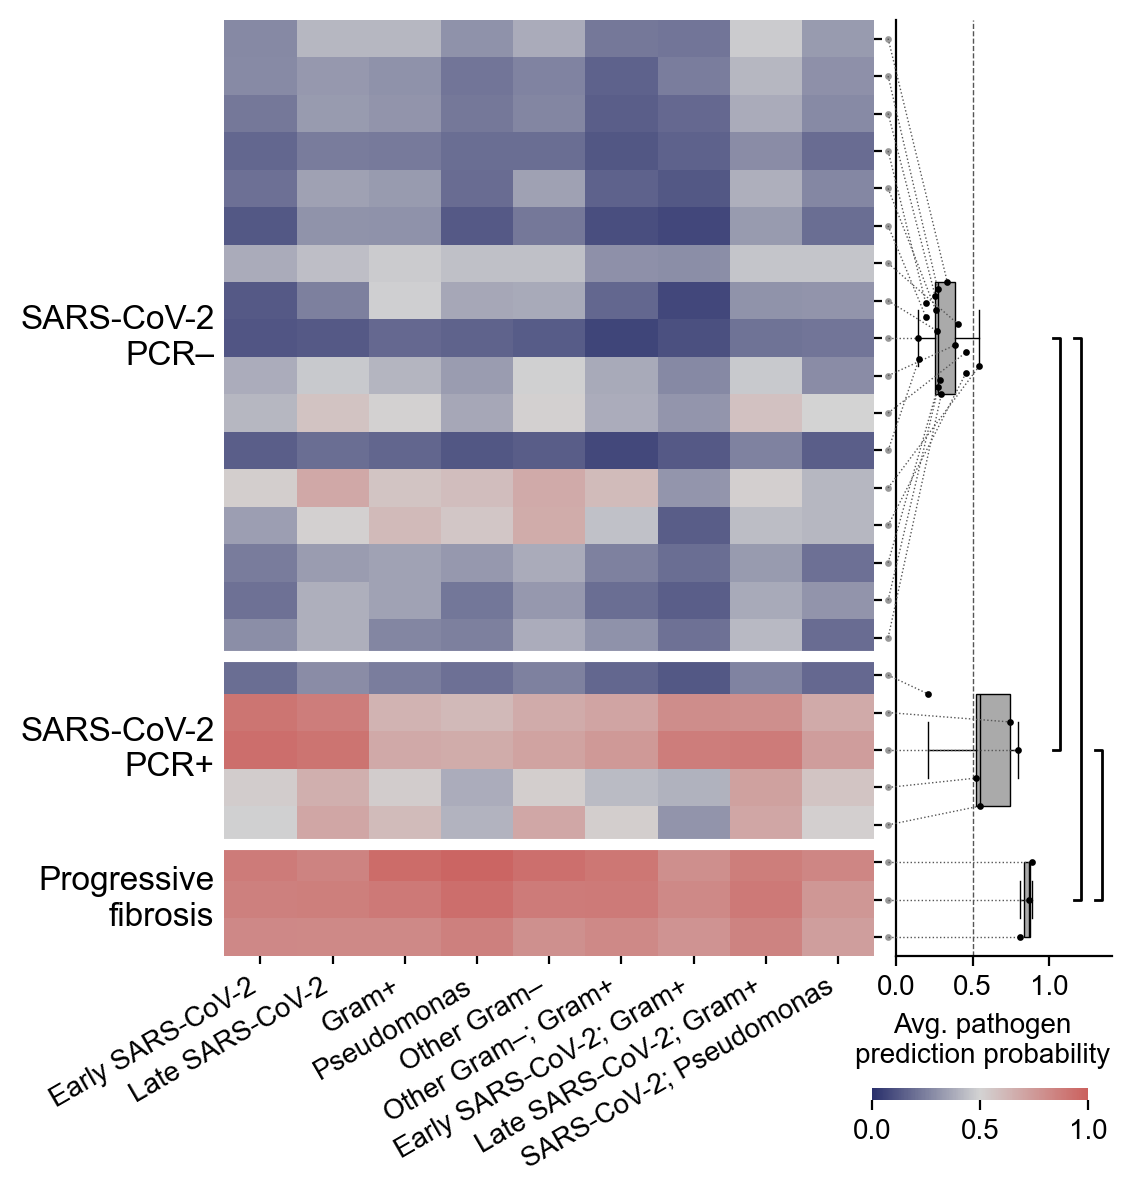

In [80]:
fig, axes = plt.subplots(figsize=(6, 6), ncols=2, sharey=True, gridspec_kw=dict(wspace=0.05, width_ratios=(3, 1)))

ax = axes[0]

pleasant_blue = '#2a306c'  # Steel Blue
pleasant_red = '#cb615e'   # Indian Red
colors = [pleasant_blue, 'lightgray', pleasant_red]
n_bins = 255
cmap = mpl.colors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

cbar_ax = fig.add_axes((0.78, 0.08, 0.18, 0.01))

sns.heatmap(
    long_covid_heatmap.loc[sample_order, TASK_ORDER],
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1,
    xticklabels=[],
    yticklabels=[],
    # yticklabels=list(lc_meta['Deidentified Subject ID'][long_covid_heatmap.index]),
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        # label='Average prediction probability',
        orientation='horizontal',
        ticks=[0, 0.5, 1]
    ),
)

for border in sample_borders[:-1]:
    ax.axhline(y=border, c='w', lw=4)

for idx, category in enumerate(CAT_ORDER):
    prev_y = 0
    if idx > 0:
        prev_y = sample_borders[idx - 1]
    ax.annotate(
        CAT_NAMES.get(category, category),
        xy=(0, prev_y + (sample_borders[idx] - prev_y) / 2),
        xytext=(-10, 0),
        textcoords='offset pixels',
        va='center',
        ha='right',
        # rotation=90,
        size=12
    )

x_ticks = []
x_tick_labels = []
for i, task in enumerate(TASK_ORDER):
    x_ticks.append(i + 0.5)
    x_tick_labels.append(TASKS_MAP[task])

ax.set_xticks(x_ticks, labels=x_tick_labels, ha='right', rotation=30)
ax.set_yticks(np.arange(len(sample_order)) + 0.5)
ax.tick_params(right=True, left=False, size=3)

# for i, sample in enumerate(long_covid_heatmap.index):
#     pcr = lc_meta['SARS-CoV-2 PCR'][lc_meta.index == sample].iloc[0]
#     if pcr == 'Positive':
#         ax.annotate(
#             '+',
#             xy=(long_covid_heatmap.shape[1], i + 0.5),
#             xytext=(10, 0),
#             textcoords='offset pixels',
#             va='center'
#         )
# ax.annotate(
#     'SARS-CoV-2 PCR',
#     xy=(long_covid_heatmap.shape[1], long_covid_heatmap.shape[0]),
#     xytext=(10, -10),
#     textcoords='offset pixels',
#     ha='left',
#     va='top',
#     rotation=90
# )

ax.set_xlabel('')
ax.set_ylabel('')

ax = axes[1]
ax.tick_params(left=False)
ax.scatter([-0.05] * len(sample_order), np.arange(len(sample_order)) + 0.5, s=2, c='#999', clip_on=False)
# ax.set_xlim(0, 1)
ax.axvline(0.5, c='#555', lw=0.5, ls='--')
ax.spines[['top', 'right']].set_visible(False)
# ax.spines[['left', 'top', 'right']].set_visible(False)

avg_preds = long_covid_heatmap.loc[sample_order].mean(axis=1).to_frame(name='avg_prob')
avg_preds['group'] = sample_groups
avg_preds['idx'] = np.arange(avg_preds.shape[0]) + 0.5
grp_mean = avg_preds.groupby('group').idx.mean()
avg_preds['group_idx'] = grp_mean[avg_preds['group'].values].values

for name, group in avg_preds.groupby('group_idx'):
    widths = 3
    if group.shape[0] < 4:
        widths = 2
    ax.boxplot(
        group.avg_prob.values,
        positions=[name],
        widths=widths,
        patch_artist=True,
        showfliers=False,
        vert=False,
        manage_ticks=False,
        boxprops=dict(color='k', lw=0.5, facecolor='#aaa'),
        whiskerprops=dict(color='k', lw=0.5),
        capprops=dict(color='k', lw=0.5),
        medianprops=dict(color='k', lw=0.5),
        zorder=3
    )
for _, row in avg_preds.iterrows():
    n_rows = (avg_preds.group_idx.eq(row.group_idx).sum() - 1) / 2
    first_row = avg_preds.idx[avg_preds.group_idx.eq(row.group_idx)].min()
    if n_rows < 2:
        offset = 1
    else:
        offset = 1.5
    y = row.group_idx - offset + (row.idx - first_row) * offset / n_rows
    ax.scatter([row.avg_prob], [y], s=2, c='k', zorder=5)
    ax.plot([-0.05, row.avg_prob], [row.idx, y], clip_on=False, c='#555', lw=0.5, ls='dotted', zorder=4)

stats_results = []
for d1, d2 in itertools.combinations(CAT_ORDER, 2):
    days1 = avg_preds.avg_prob[avg_preds.group.eq(d1)].dropna()
    days2 = avg_preds.avg_prob[avg_preds.group.eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

start_height = avg_preds.avg_prob.max()
incrementer = 10 # px
labels = CAT_ORDER
q = ax.transData.inverted().transform([[0, 0], [incrementer, 0]])
x_offset = q[1][0] - q[0][0]
gap = x_offset / 2
x = start_height + x_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        y1, y2 = (
            avg_preds.group_idx[avg_preds.group.eq(r.group1)].iloc[0],
            avg_preds.group_idx[avg_preds.group.eq(r.group2)].iloc[0]
        )
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        y1, y2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    x += gap

    bracket = ax.plot([x, x+h, x+h, x], [y1, y1, y2, y2], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    x += x_offset

ax.set_xlim(0)
ax.set_xticks([0, 0.5, 1])
ax.set_xlabel('Avg. pathogen\nprediction probability', x=0.4)
fig.subplots_adjust(top=0.98, right=0.98, bottom=0.2, left=0.24)
fig.savefig('00_plots/05b_long_covid_heatmap.pdf')

In [33]:
supp_data = pd.read_excel('../data/00_metadata/Supplemental Data File 1. Metadata for RPRA cohort.xlsx', index_col=0)

In [34]:
lc_meta = lc_meta.reset_index().merge(
    supp_data,
    left_on='Deidentified Subject ID',
    right_index=True,
    how='left'
).set_index('individual')

In [35]:
lc_meta.shape

(25, 46)

## Boxplots

In [72]:
avg_preds = long_covid_heatmap.mean(axis=1).to_frame(name='avg_prob')

In [73]:
avg_preds['group'] = lc_meta['SARS-CoV-2 PCR']

In [74]:
avg_preds.loc[avg_preds.index.str.startswith('LT'), 'group'] = 'Transplant'

In [75]:
avg_preds.group = avg_preds.group.replace({'Positive': '+', 'Negative': '—'})

In [76]:
GROUP_ORDER = ['Transplant', '—', '+']

/tmp/ipykernel_1458821/1792150339.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=avg_preds, x='group', y='avg_prob', order=GROUP_ORDER, ax=ax, palette=['k'])
/tmp/ipykernel_1458821/1792150339.py:20: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=avg_preds, x='group', y='avg_prob', order=GROUP_ORDER, ax=ax, palette=['k'])
/tmp/ipykernel_1458821/1792150339.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(GROUP_ORDER)


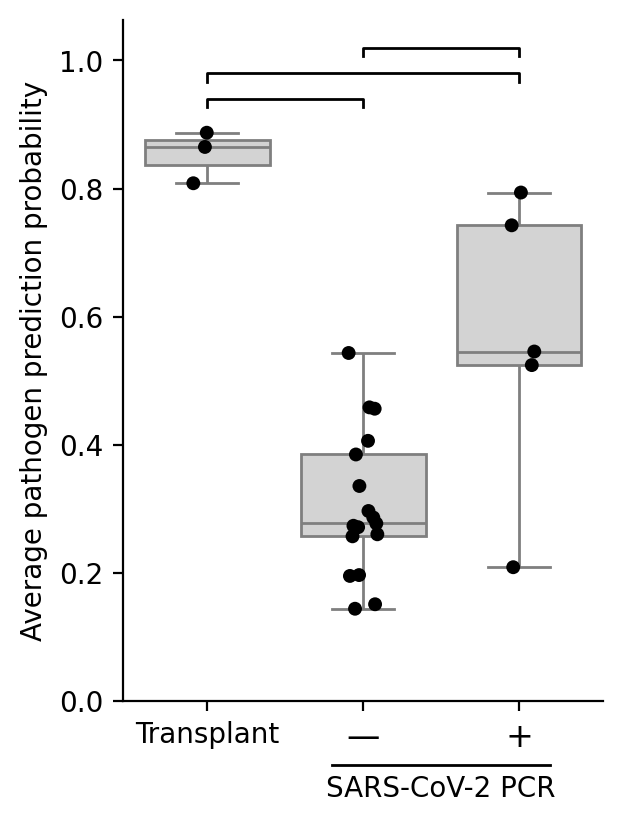

In [78]:
fig, ax = plt.subplots(figsize=(3, 4), constrained_layout=True)

stats_results = []
for d1, d2 in itertools.combinations(GROUP_ORDER, 2):
    days1 = avg_preds.avg_prob[avg_preds.group.eq(d1)].dropna()
    days2 = avg_preds.avg_prob[avg_preds.group.eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(data=avg_preds, x='group', y='avg_prob', order=GROUP_ORDER, ax=ax, color='lightgray')
sns.stripplot(data=avg_preds, x='group', y='avg_prob', order=GROUP_ORDER, ax=ax, palette=['k'])
ax.set_xticklabels(GROUP_ORDER)
ax.set_xlabel('')
ax.set_ylabel('Average pathogen prediction probability')
ax.spines[['top', 'right']].set_visible(False)

start_height = avg_preds.avg_prob.max()
incrementer = 10 # px
labels = GROUP_ORDER
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

ax.set_ylim(0)
ax.text(1.5, -0.15, 'SARS-CoV-2 PCR', ha='center')
ax.plot([0.8, 2.2], [-0.1, -0.1], clip_on=False, color='k', lw=1)
ax.get_xticklabels()[1].set_size(12)
ax.get_xticklabels()[2].set_size(12)
fig.savefig('00_plots/05b_long_covid_boxplots.pdf')